In [1]:
import os

os.chdir("../")

## Imports

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.io import loadmat
from statannotations.Annotator import Annotator

from src._config import IMG_DIR, MIN_BELIEF, MIN_SHOCKS, MAX_SHOCKS, N_OPPONENTS, N_TRIALS

FIG1_DIR = Path(IMG_DIR) / "fig1"
os.makedirs(FIG1_DIR, exist_ok=True)

## Fig 1a-c: see paper
### Supplementary Fig. 1: see paper

## Data

In [20]:
script = pd.read_excel("data/shared/AggressionScript.xlsx", index_col="Session")
shocked = script.loc["Shocked"].values.astype(int)
outliers = loadmat("data/cohort_a/outliers.mat", squeeze_me=True)["outliers"]

### Supplementary Fig. 2: participant exclusion

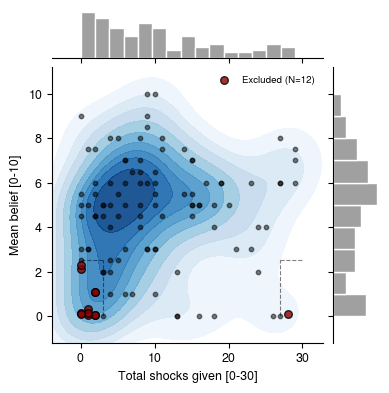

Excluded: 12 / 126 participants
Excluded subjects: ['P041', 'P044', 'P068', 'P077', 'P078', 'P088', 'P104', 'P125', 'P127', 'P132', 'P164', 'P176']


In [31]:
aggro_performance = pd.read_excel(
    Path("data", "cohort_a", "aggroPerformance.xlsx"), index_col="Subject"
)
# Total shocks per subject (from aggro_performance directly, not melted data)
shock_cols_only = [c for c in aggro_performance.columns if c.startswith("shock")]
total_shocks = aggro_performance[shock_cols_only].sum(axis=1)

# Load belief data
opponent_beliefs = pd.read_excel(
    Path("data", "cohort_a", "beliefs.xlsx"), index_col="ID"
)
if sorted(opponent_beliefs.columns) != ["opponent1", "opponent2"]:
    opponent_beliefs.rename(
        columns={k: k[4:] + k[0] for k in opponent_beliefs.columns}, inplace=True
    )
opponent_beliefs.drop("opponent3", axis=1, errors="ignore", inplace=True)

# Total shocks per subject (from aggro_performance directly, not melted data)
shock_cols_only = [c for c in aggro_performance.columns if c.startswith("shock")]
total_shocks = aggro_performance[shock_cols_only].sum(axis=1)

# Mean belief per subject
mean_belief = opponent_beliefs.mean(axis=1)

# Align indices
common_subj = total_shocks.index.intersection(mean_belief.dropna().index)
total_shocks = total_shocks.loc[common_subj]
mean_belief = mean_belief.loc[common_subj]

# Identify outliers: low belief AND extreme shocks
outliers = ((total_shocks < MIN_SHOCKS) | (total_shocks > MAX_SHOCKS)) & (
    mean_belief < MIN_BELIEF
)

with plt.style.context(".matplotlib/paper.mplstyle"):
    g = sns.JointGrid(x=total_shocks, y=mean_belief, height=4)

    # Center: KDE + scatter
    sns.kdeplot(
        x=total_shocks,
        y=mean_belief,
        cut=1,
        cmap=sns.color_palette("Blues", as_cmap=True),
        fill=True,
        alpha=0.9,
        ax=g.ax_joint,
    )
    g.ax_joint.scatter(
        total_shocks[~outliers],
        mean_belief[~outliers],
        color="k",
        s=10,
        alpha=0.5,
        zorder=3,
    )

    # Excluded subjects with jitter (clamped to >= 0)
    np.random.seed(42)
    jitter_y = np.abs(np.random.normal(0, 0.2, size=outliers.sum()))
    g.ax_joint.scatter(
        total_shocks[outliers],
        mean_belief[outliers] + jitter_y,
        color="darkred",
        edgecolor="k",
        s=30,
        alpha=0.8,
        zorder=5,
        label=f"Excluded (N={outliers.sum()})",
    )

    # Threshold lines (clipped to data range)
    g.ax_joint.plot(
        [MIN_SHOCKS, MIN_SHOCKS],
        [0, MIN_BELIEF],
        linestyle="--",
        color="k",
        alpha=0.5,
        linewidth=0.8,
    )
    g.ax_joint.plot(
        [MAX_SHOCKS, MAX_SHOCKS],
        [0, MIN_BELIEF],
        linestyle="--",
        color="k",
        alpha=0.5,
        linewidth=0.8,
    )
    g.ax_joint.plot(
        [0, MIN_SHOCKS],
        [MIN_BELIEF, MIN_BELIEF],
        linestyle="--",
        color="k",
        alpha=0.5,
        linewidth=0.8,
    )
    g.ax_joint.plot(
        [MAX_SHOCKS, 30],
        [MIN_BELIEF, MIN_BELIEF],
        linestyle="--",
        color="k",
        alpha=0.5,
        linewidth=0.8,
    )

    # Marginals: histograms
    sns.histplot(
        x=total_shocks, ax=g.ax_marg_x, color="gray", bins=15, edgecolor="white"
    )
    sns.histplot(
        y=mean_belief, ax=g.ax_marg_y, color="gray", bins=10, edgecolor="white"
    )

    g.ax_joint.set_xlabel("Total shocks given [0-30]")
    g.ax_joint.set_ylabel("Mean belief [0-10]")
    g.ax_joint.legend(fontsize=7, loc="upper right")

    plt.savefig(FIG1_DIR / "shock_vs_belief.pdf", bbox_inches="tight")
    plt.savefig(FIG1_DIR / "shock_vs_belief.png", dpi=300, bbox_inches="tight")
    plt.show()

print(f"Excluded: {outliers.sum()} / {len(aggro_performance)} participants")
print(f"Excluded subjects: {sorted(outliers[outliers].index.tolist())}")

## Fig 1d: shocks given vs. opponent (Cohort A)

In [20]:
# Posterior predictions and Bayes factors for shock overview

shock_posterior = pd.read_csv("data/brms/shocks_overview/posterior_epred.csv")
bf_shocks = pd.read_csv("data/brms/shocks_overview/bayes_factors.csv")

# Cohort A only
shock_post_a = shock_posterior[shock_posterior["cohort"] == "A"]

/tmp/ipykernel_3516348/1837098238.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


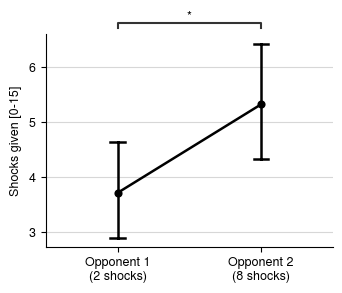

In [11]:
with plt.style.context(".matplotlib/paper.mplstyle"):
    plot_dict = {
        "data": shock_post_a,
        "x": "opponent",
        "y": "shocks",
    }

    fig, ax = plt.subplots(figsize=(3.5, 3))
    sns.pointplot(
        **plot_dict,
        color="k",
        capsize=0.1,
        errorbar=("pi", 95),
        ax=ax,
    )
    ax.set_xticklabels(
        [
            f"Opponent {i + 1}\n({shocked[i * N_TRIALS:(i + 1) * N_TRIALS].sum()} shocks)"
            for i in range(N_OPPONENTS)
        ]
    )
    ax.set_ylabel("Shocks given [0-15]")
    ax.set_xlabel("")
    ax.grid(alpha=0.5, axis="y", zorder=0)

    bf_a = bf_shocks[(bf_shocks["cohort"] == "A") & bf_shocks["excl_zero"]]
    if not bf_a.empty:
        annotator = Annotator(
            ax,
            pairs=[("Opponent 1", "Opponent 2")],
            **plot_dict,
            verbose=False,
        )
        annotator.configure(loc="outside", verbose=False)
        annotator.set_custom_annotations(["*"])
        annotator.annotate()

    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.savefig(FIG1_DIR / "shocks_given.pdf", bbox_inches="tight")
    plt.savefig(FIG1_DIR / "shocks_given.png", dpi=300, bbox_inches="tight")
    plt.show()

### Supplementary Table 1

In [38]:
print(bf_shocks.set_index("contrast").round(3).to_markdown())

| contrast                | cohort   |   estimate |   lower.HPD |   upper.HPD |      BF10 | excl_zero   |
|:------------------------|:---------|-----------:|------------:|------------:|----------:|:------------|
| Opponent 1 - Opponent 2 | A        |     -0.519 |      -0.687 |      -0.36  | 32947.3   | True        |
| Opponent 1 - Opponent 2 | B        |     -0.286 |      -0.557 |      -0.024 |     0.976 | True        |


In [21]:
# Opponent effect: absolute difference (count scale)
wide = shock_post_a.pivot_table(index=".draw", columns="opponent", values="shocks")
diff = wide["Opponent 2"] - wide["Opponent 1"]
print(
    f"Difference: {diff.mean():.1f} [{diff.quantile(0.025):.1f}, {diff.quantile(0.975):.1f}]"
)

# Opponent effect: odds ratio
log_or = -bf_shocks.query("cohort == 'A'")["estimate"].values[
    0
]  # flip sign for Opp2/Opp1
or_val = np.exp(log_or)
or_lo = np.exp(-bf_shocks.query("cohort == 'A'")["upper.HPD"].values[0])
or_hi = np.exp(-bf_shocks.query("cohort == 'A'")["lower.HPD"].values[0])
print(f"OR (Opp2/Opp1): {or_val:.2f} [{or_lo:.2f}, {or_hi:.2f}]")

Difference: 1.6 [1.1, 2.2]
OR (Opp2/Opp1): 1.68 [1.43, 1.99]


## Fig. 1e: trial duration vs. decision

In [35]:
trials = pd.read_csv("data/shared/trial_events.csv")
trials_clean = trials[trials["duration"].between(0, 30)]

trials_a = trials_clean[trials_clean["cohort"] == "A"]
trials_a = trials_a[~trials_a["subject"].isin(outliers)]
trials_a["decision"] = trials_a["choice"].map(
    {"ring": "Loop enlarged", "shock": "Shock given", float("nan"): "Nothing"}
)

print(trials_a.groupby("decision").size().sort_values(ascending=False).rename("count").to_markdown())

| decision      |   count |
|:--------------|--------:|
| Loop enlarged |    2044 |
| Shock given   |    1205 |
| Nothing       |     200 |


In [39]:
duration_posterior = pd.read_csv("data/brms/trial_duration/posterior_epred.csv")
bf_duration = pd.read_csv("data/brms/trial_duration/bayes_factors.csv")

/tmp/ipykernel_3516348/1881577530.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


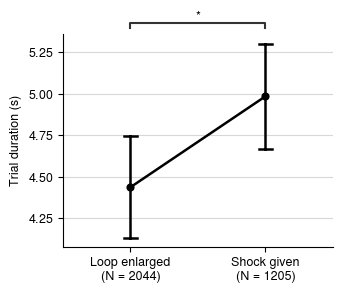

In [41]:
# Cohort A only
dur_post_a = duration_posterior.query("cohort == 'A' & decision != 'Nothing'")

decision_order = ["Enlarge", "Shock"]


def parse_contrast(c):
    parts = c.split(" - ")
    return parts[0].strip("() "), parts[1].strip("() ")

with plt.style.context(".matplotlib/paper.mplstyle"):
    plot_dict = {
        "data": dur_post_a,
        "x": "decision",
        "y": "duration",
    }

    fig, ax = plt.subplots(figsize=(3.5, 3))
    sns.pointplot(
        **plot_dict,
        order=decision_order,
        color="k",
        capsize=0.1,
        errorbar=("pi", 95),
        ax=ax,
    )
    counts = trials_a.groupby("decision").size()
    labels = [f"{d}\n(N = {counts[d]})" for d in ["Loop enlarged", "Shock given"]]
    ax.set_xticklabels(labels)
    ax.set_ylabel("Trial duration (s)")
    ax.set_xlabel("")
    ax.grid(alpha=0.5, axis="y", zorder=0)

    sig_a = bf_duration[(bf_duration["cohort"] == "A") & bf_duration["excl_zero"]]
    pairs = []
    for _, row in sig_a.iterrows():
        c1, c2 = parse_contrast(row["contrast"])
        if c1 in decision_order and c2 in decision_order:
            pairs.append((c1, c2))

    if pairs:
        annotator = Annotator(
            ax,
            pairs=pairs,
            **plot_dict,
            order=decision_order,
            verbose=False,
        )
        annotator.configure(loc="outside", verbose=False)
        annotator.set_custom_annotations(["*"] * len(pairs))
        annotator.annotate()

    ax.yaxis.set_major_locator(plt.MultipleLocator(0.25))
    plt.savefig(FIG1_DIR / "trial_duration.pdf", bbox_inches="tight")
    plt.savefig(FIG1_DIR / "trial_duration.png", dpi=300, bbox_inches="tight")
    plt.show()

### Supplementary Table 2

In [40]:
print(bf_duration.set_index("contrast").round(3).to_markdown())

| contrast          | cohort   |   estimate |   lower.HPD |   upper.HPD |         BF10 | excl_zero   |
|:------------------|:---------|-----------:|------------:|------------:|-------------:|:------------|
| Enlarge - Shock   | A        |     -0.547 |      -0.67  |      -0.419 |  7.90175e+06 | True        |
| Enlarge - Nothing | A        |     -0.118 |      -0.342 |       0.108 |  0.189       | False       |
| Shock - Nothing   | A        |      0.428 |       0.19  |       0.659 | 38.176       | True        |
| Enlarge - Shock   | B        |     -0.748 |      -0.959 |      -0.539 |  6.68165e+06 | True        |
| Enlarge - Nothing | B        |     -0.153 |      -0.638 |       0.337 |  0.213       | False       |
| Shock - Nothing   | B        |      0.594 |       0.09  |       1.081 |  1.934       | True        |


In [22]:
# Trial duration: absolute difference (Shock - Enlarge, Cohort A)
row = bf_duration.query("cohort == 'A' & contrast == 'Enlarge - Shock'").iloc[0]
print(
    f"Difference: {-row['estimate']:.2f} s [{-row['upper.HPD']:.2f}, {-row['lower.HPD']:.2f}]"
)

# Trial duration: relative difference
means = duration_posterior.query("cohort == 'A' & decision != 'Nothing'")
wide = means.pivot_table(index=".draw", columns="decision", values="duration")
pct = (wide["Shock"] - wide["Enlarge"]) / wide["Enlarge"] * 100
print(
    f"Relative: {pct.mean():.1f}% [{pct.quantile(0.025):.1f}%, {pct.quantile(0.975):.1f}%]"
)

Difference: 0.55 s [0.42, 0.67]
Relative: 12.4% [9.3%, 15.5%]
